In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("delhi_pm25_features.csv")

In [4]:
print(df.shape)
print(df.columns)
print(df.info())
print(df.isnull().sum())
print(df.head())

(16630, 20)
Index(['datetime', 'location', 'latitude', 'longitude', 'pm25', 'hour', 'dow',
       'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'pm25_lag_1h',
       'pm25_lag_3h', 'pm25_lag_6h', 'pm25_lag_12h', 'pm25_lag_24h',
       'pm25_rolling_mean_3h', 'pm25_rolling_mean_6h', 'pm25_rolling_mean_24h',
       'pm25_rolling_std_6h'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 16630 entries, 0 to 16629
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   datetime               16630 non-null  str    
 1   location               16630 non-null  str    
 2   latitude               16630 non-null  float64
 3   longitude              16630 non-null  float64
 4   pm25                   15747 non-null  float64
 5   hour                   16630 non-null  int64  
 6   dow                    16630 non-null  int64  
 7   hour_sin               16630 non-null  float64
 8   hour_cos           

<Axes: >

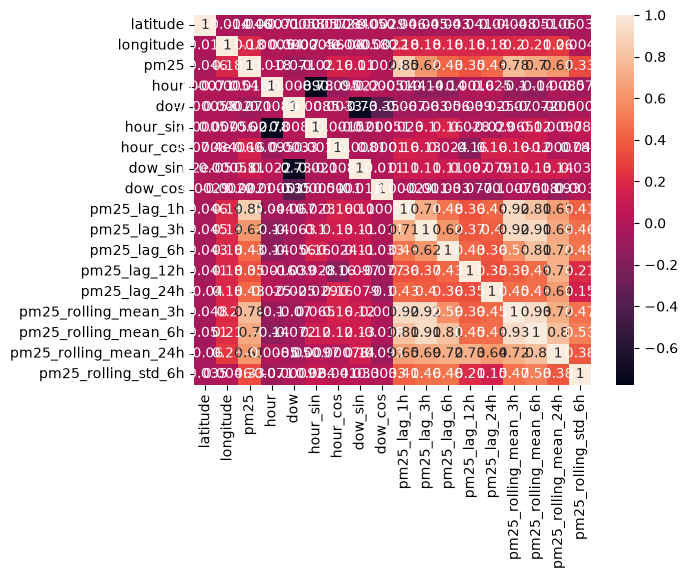

In [5]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

<Axes: xlabel='location', ylabel='pm25'>

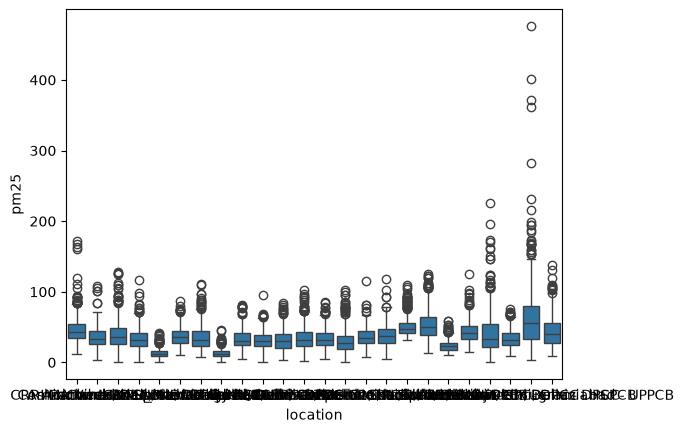

In [6]:
sns.boxplot(data=df,x='location',y='pm25')

In [7]:
df["datetime"] = pd.to_datetime(df["datetime"])
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 16630 entries, 0 to 16629
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype                    
---  ------                 --------------  -----                    
 0   datetime               16630 non-null  datetime64[us, UTC+05:30]
 1   location               16630 non-null  str                      
 2   latitude               16630 non-null  float64                  
 3   longitude              16630 non-null  float64                  
 4   pm25                   15747 non-null  float64                  
 5   hour                   16630 non-null  int64                    
 6   dow                    16630 non-null  int64                    
 7   hour_sin               16630 non-null  float64                  
 8   hour_cos               16630 non-null  float64                  
 9   dow_sin                16630 non-null  float64                  
 10  dow_cos                16630 non-null  float64           

In [8]:


df = df.sort_values(
    ["location", "datetime"]
).reset_index(drop=True)

df["pm25"] = (
    df.groupby("location")["pm25"]
      .transform(lambda x: x.interpolate(method="linear"))
)

print(df.isnull().sum())

datetime                    0
location                    0
latitude                    0
longitude                   0
pm25                        0
hour                        0
dow                         0
hour_sin                    0
hour_cos                    0
dow_sin                     0
dow_cos                     0
pm25_lag_1h               907
pm25_lag_3h               955
pm25_lag_6h              1027
pm25_lag_12h             1171
pm25_lag_24h             1459
pm25_rolling_mean_3h      812
pm25_rolling_mean_6h      902
pm25_rolling_mean_24h    1084
pm25_rolling_std_6h       902
dtype: int64


In [9]:
df["target_pm25"] = (
    df.groupby("location")["pm25"].shift(-1)
)
print(df.head)

<bound method NDFrame.head of                        datetime                           location   latitude  \
0     2026-08-05 10:00:00+05:30                          Air Check  28.623056   
1     2026-08-05 11:00:00+05:30                          Air Check  28.623056   
2     2026-08-05 12:00:00+05:30                          Air Check  28.623056   
3     2026-08-05 13:00:00+05:30                          Air Check  28.623056   
4     2026-08-05 14:00:00+05:30                          Air Check  28.623056   
...                         ...                                ...        ...   
16625 2026-09-02 19:00:00+05:30  Ved Vihar-Loni, Ghaziabad - UPPCB  28.739153   
16626 2026-09-02 20:00:00+05:30  Ved Vihar-Loni, Ghaziabad - UPPCB  28.739153   
16627 2026-09-02 21:00:00+05:30  Ved Vihar-Loni, Ghaziabad - UPPCB  28.739153   
16628 2026-09-02 22:00:00+05:30  Ved Vihar-Loni, Ghaziabad - UPPCB  28.739153   
16629 2026-09-02 23:00:00+05:30  Ved Vihar-Loni, Ghaziabad - UPPCB  28.739153  

In [10]:
df["target_pm25"] = df.groupby("location")["pm25"].shift(-1)

df = df.dropna(subset=["target_pm25"])

In [11]:
features = [
    "location",
    "latitude",
    "longitude",
    "pm25",
    "pm25_lag_1h",
    "pm25_lag_3h",
    "pm25_lag_6h",
    "pm25_lag_12h",
    "pm25_lag_24h",
    "pm25_rolling_mean_3h",
    "pm25_rolling_mean_6h",
    "pm25_rolling_mean_24h",
    "pm25_rolling_std_6h",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos"
]

X = df[features]
y = df["target_pm25"]

In [12]:


X_one_encode = pd.get_dummies(
    X,
    columns=['location'],
    drop_first=True,
    dtype=int
)

num_cols = X_one_encode.select_dtypes(include=['number']).columns

X_one_encode[num_cols] = X_one_encode[num_cols].fillna(
    X_one_encode[num_cols].median()
)

print(X_one_encode.head())
print(X_one_encode.isna().sum())

    latitude  longitude  pm25  pm25_lag_1h  pm25_lag_3h  pm25_lag_6h  \
0  28.623056  77.234167  62.7         33.5         33.5         33.6   
1  28.623056  77.234167  56.8         62.7         33.5         33.6   
2  28.623056  77.234167  68.6         56.8         33.5         33.6   
3  28.623056  77.234167  71.5         68.6         62.7         33.6   
4  28.623056  77.234167  69.9         71.5         56.8         33.6   

   pm25_lag_12h  pm25_lag_24h  pm25_rolling_mean_3h  pm25_rolling_mean_6h  \
0          33.7          33.7             33.666667                 33.95   
1          33.7          33.7             62.700000                 33.95   
2          33.7          33.7             59.750000                 33.95   
3          33.7          33.7             62.700000                 62.70   
4          33.7          33.7             65.633333                 64.90   

   ...  location_Santushti Apartments, Vasant Kunj  \
0  ...                                           0

In [13]:
n = len(df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score
from xgboost import XGBRegressor

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X_one_encode, y, test_size=0.2, random_state=42)

In [16]:
print("Missing y_train:", y_train.isna().sum())
print("Missing X_train:", X_train.isna().sum().sum())

Missing y_train: 0
Missing X_train: 0


In [17]:
xgb_model=XGBRegressor(n_estimators=100,learning_rate=0.1,max_depth=3,random_state=42)
xgb_model.fit(X_train,y_train)
y_pred=xgb_model.predict(X_test)
r2=r2_score(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mean_squared_error(y_test,y_pred))

In [18]:
print("r2: ",r2)
print("mae: ",mae)
print("rmse: ",rmse)

r2:  0.7780500214058914
mae:  5.321588340542169
rmse:  9.799088587501236


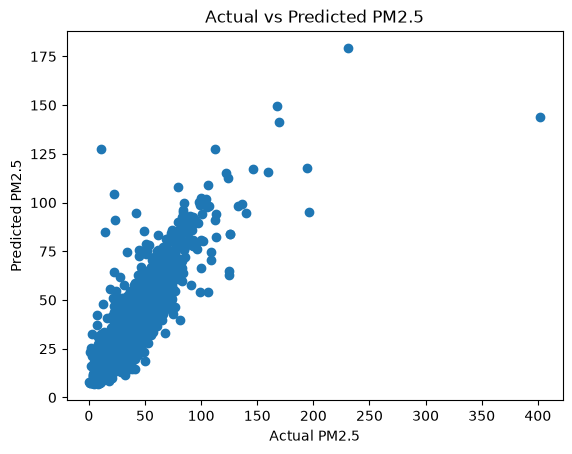

In [19]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("Actual vs Predicted PM2.5")
plt.show()